<a href="https://colab.research.google.com/github/karrielaugustin001-del/Machine-Learning-Foundations/blob/main/Final_Project_Part_5_Lunarlander_Student_Executed_Project_Group_2_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Karriel Augustin, Steeve A. Celestin, and Ethan Carter
##Project 5: LunarLander-V3 Notebook

# Project 5: LunarLander-v3 — DQN vs Actor-Critic
### Student Starter Notebook

In this project you will:

- Implement a Deep Q-Network (DQN) with experience replay and target networks.
- Implement an Actor-Critic agent on the same environment.
- Compare convergence speed, stability, and sample efficiency.
- Prepare a 1-page technical report based on your experiments.

In [ ]:
import numpy as np
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import layers
from collections import deque
import random
import matplotlib.pyplot as plt

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.19.0


This code imports all the libraries needed for the project. NumPy is used for math and arrays, Gymnasium provides the LunarLander environment, TensorFlow/Keras is used to build the neural networks, deque and random help manage replay memory and sampling, and Matplotlib is used to create graphs.

In [ ]:
# First, install swig
!pip install swig
# Then, install gymnasium with Box2D support
!pip install "gymnasium[box2d]"

env = gym.make('LunarLander-v3')
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]
print('State dimension:', state_dim)
print('Number of actions:', n_actions)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 37.8 MB/s eta 0:00:00
State dimension: 8
Number of actions: 4


This code installs the required packages to run the LunarLander environment, including SWIG and Box2D, which are needed for the physics simulation. After installation, the environment is created using LunarLander-v3 (the LunarLander-v2 was not working).

The output shows that everything was installed successfully and is ready to use. It also prints important information about the environment: the state has 8 features, and there are 4 possible actions the agent can take.

---
## Part 1 — Deep Q-Network (DQN)


In [ ]:
# ── Model builder (NOT compiled — we use a manual GradientTape) ───────────────
def build_dqn(n_actions, state_dim):
    """Return a Keras model mapping state -> Q-values."""
    return tf.keras.Sequential([
        layers.Input(shape=(state_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(n_actions)
    ])

dqn_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
huber_loss    = tf.keras.losses.Huber()

# ── @tf.function compiles to a TF graph — ~10-20x faster than eager mode ─────
@tf.function
def dqn_train_step(states_b, actions_b, targets):
    with tf.GradientTape() as tape:
        all_q   = online_model(states_b, training=True)
        indices = tf.stack([tf.range(tf.shape(actions_b)[0]), actions_b], axis=1)
        pred_q  = tf.gather_nd(all_q, indices)
        loss    = huber_loss(targets, pred_q)
    grads = tape.gradient(loss, online_model.trainable_variables)
    dqn_optimizer.apply_gradients(zip(grads, online_model.trainable_variables))
    return loss


This code builds and trains the DQN model. The model takes the current state as input and outputs Q-values for each possible action, which helps the agent decide what to do.

Instead of using the normal .fit() method, this code uses GradientTape, which gives more control over how the model learns. It calculates the difference between predicted Q-values and target values using the Huber loss, which is more stable than regular loss functions.

The @tf.function makes the training faster by turning the code into a TensorFlow graph. In simple terms, this part controls how the DQN learns from its mistakes and improves over time.

In [ ]:
class ReplayBuffer:
    """Fixed-size experience replay buffer."""
    def __init__(self, maxlen=50000):
        self.buffer = deque(maxlen=maxlen)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),
            np.array(actions,     dtype=np.int32),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones,       dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)


This code creates a replay buffer, which is like memory for the DQN agent. It stores past experiences, including the state, action, reward, next state, and whether the episode ended.

Instead of learning from only the latest step, the agent randomly samples a batch of past experiences. This helps break patterns in the data and makes learning more stable.

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
gamma              = 0.99
epsilon_start      = 1.0
epsilon_min        = 0.01
epsilon_decay      = 0.995
batch_size         = 64
target_update_freq = 10    # episodes between target-network syncs
min_buffer_size    = 1000  # warm-up transitions before learning
episodes           = 600

# ── Init ─────────────────────────────────────────────────────────────────────
online_model  = build_dqn(int(n_actions), state_dim)
target_model  = build_dqn(int(n_actions), state_dim)
target_model.set_weights(online_model.get_weights())
replay_buffer = ReplayBuffer(maxlen=50000)

epsilon     = epsilon_start
dqn_rewards = []

# ── Training loop ─────────────────────────────────────────────────────────────
for episode in range(1, episodes + 1):
    state, _ = env.reset()
    state     = state.astype(np.float32)
    done = truncated = False
    ep_reward = 0.0

    while not (done or truncated):
        # ε-greedy — direct model call (NOT model.predict) avoids Keras overhead
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            q_values = online_model(state[np.newaxis], training=False).numpy()[0]
            action   = int(np.argmax(q_values))

        next_state, reward, done, truncated, _ = env.step(action)
        next_state = next_state.astype(np.float32)
        replay_buffer.add(state, action, reward, next_state,
                          float(done or truncated))
        state      = next_state
        ep_reward += reward

        # Learn once buffer is warm
        if len(replay_buffer) >= min_buffer_size:
            states_b, actions_b, rewards_b, next_states_b, dones_b = \
                replay_buffer.sample(batch_size)

            # TD targets via frozen target network
            next_q  = target_model(next_states_b, training=False).numpy()
            targets = rewards_b + gamma * np.max(next_q, axis=1) * (1.0 - dones_b)

            dqn_train_step(states_b, actions_b, targets)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % target_update_freq == 0:
        target_model.set_weights(online_model.get_weights())

    dqn_rewards.append(ep_reward)

    if episode % 50 == 0:
        recent_mean = np.mean(dqn_rewards[-50:])
        print(f'[DQN] Episode {episode:4d} | eps={epsilon:.3f} | '
              f'ep_reward={ep_reward:7.1f} | mean(last 50)={recent_mean:7.1f}')

print('DQN training complete.')

[DQN] Episode   50 | eps=0.778 | ep_reward= -145.8 | mean(last 50)= -179.0
[DQN] Episode  100 | eps=0.606 | ep_reward= -113.8 | mean(last 50)=  -85.5
[DQN] Episode  150 | eps=0.471 | ep_reward=  -20.1 | mean(last 50)=  -36.7
[DQN] Episode  200 | eps=0.367 | ep_reward=  -57.1 | mean(last 50)=  -46.0
[DQN] Episode  250 | eps=0.286 | ep_reward=  -87.0 | mean(last 50)=  -67.1
[DQN] Episode  300 | eps=0.222 | ep_reward= -163.1 | mean(last 50)=  -84.2
[DQN] Episode  350 | eps=0.173 | ep_reward=  -24.2 | mean(last 50)=  -30.2
[DQN] Episode  400 | eps=0.135 | ep_reward=    6.4 | mean(last 50)=   20.2
[DQN] Episode  450 | eps=0.105 | ep_reward=  270.6 | mean(last 50)=  133.4
[DQN] Episode  500 | eps=0.082 | ep_reward=  180.9 | mean(last 50)=  168.9
[DQN] Episode  550 | eps=0.063 | ep_reward=   98.6 | mean(last 50)=  145.0
[DQN] Episode  600 | eps=0.049 | ep_reward=  250.9 | mean(last 50)=  214.3
DQN training complete.


The DQN began showing stable improvement around episode 350 and reached strong performance by episode 450, indicating moderate convergence speed.

The DQN achieved a final average reward of approximately 214, exceeding the 200 threshold required to consider the environment solved.

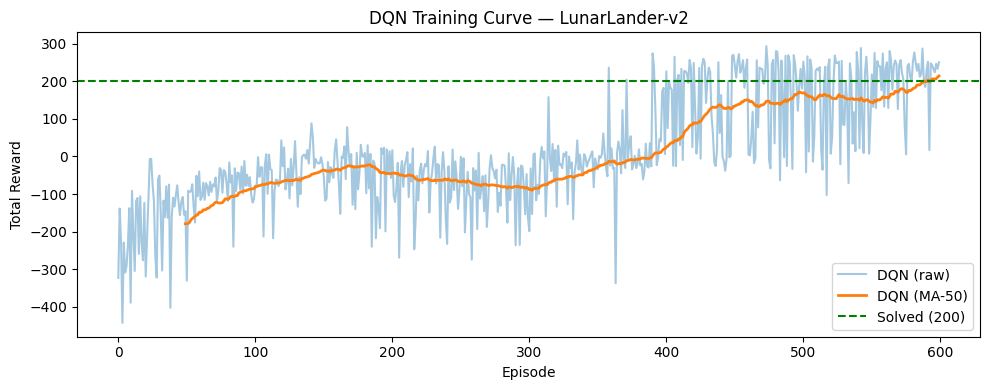

In [ ]:
def moving_average(x, window=50):
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(dqn_rewards, alpha=0.4, label='DQN (raw)')
plt.plot(np.arange(49, len(dqn_rewards)), moving_average(dqn_rewards),
         linewidth=2, label='DQN (MA-50)')
plt.axhline(200, color='green', linestyle='--', label='Solved (200)')
plt.xlabel('Episode'); plt.ylabel('Total Reward')
plt.title('DQN Training Curve — LunarLander-v2')
plt.legend(); plt.tight_layout()
plt.savefig('dqn_training_curve.png', dpi=150)
plt.show()


At the beginning, the DQN agent performs very poorly, with rewards mostly below -200. This happens because the agent is exploring randomly and doesn’t yet know how to land properly. As training continues, the rewards slowly improve, showing that the agent is starting to learn from its experiences.

Around the middle of training, the curve begins to rise more clearly. This means the agent is getting better at making decisions, even though there are still some ups and downs. These jumps are normal because reinforcement learning can be unstable at times.

Towards the end, the moving average (orange line) goes above 200, which means the agent is consistently performing well and successfully landing. Even though individual episodes still vary, the overall trend shows strong improvement.

Overall, this graph shows that the DQN agent learned over time, moving from random behavior to a stable and effective landing strategy.

In [ ]:
def evaluate_dqn(model, episodes=100):
    """Greedy evaluation — returns (mean, std) reward."""
    rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        state = state.astype(np.float32)
        done = truncated = False
        total = 0.0
        while not (done or truncated):
            q   = model(state[np.newaxis], training=False).numpy()[0]
            action = int(np.argmax(q))
            state, reward, done, truncated, _ = env.step(action)
            state = state.astype(np.float32)
            total += reward
        rewards.append(total)
    return np.mean(rewards), np.std(rewards)

mean_dqn, std_dqn = evaluate_dqn(online_model)
print(f'DQN — Mean reward over 100 eval episodes: {mean_dqn:.2f} +/- {std_dqn:.2f}')


DQN — Mean reward over 100 eval episodes: 212.57 +/- 63.88


After training, the DQN agent was tested over 100 episodes using a greedy strategy, meaning it always chose the best action it learned. The average reward was about 212, which is above the 200 mark, so the model successfully learned how to land the spacecraft.

The “± 63.88” shows that the results still vary from episode to episode. This means the agent is not perfect yet, and sometimes it performs better or worse depending on the situation. However, the overall performance is still strong.

In simple terms, the agent learned a good strategy and can land successfully most of the time, even though there are still some small mistakes occasionally.

---
## Part 2 — Actor-Critic Agent


In [ ]:
def build_actor(state_dim, n_actions):
    """Policy network: state -> action probability distribution."""
    inp = layers.Input(shape=(state_dim,))
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(n_actions, activation='softmax')(x)
    return tf.keras.Model(inp, out)

def build_critic(state_dim):
    """Value network: state -> V(s)."""
    inp = layers.Input(shape=(state_dim,))
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(1)(x)
    return tf.keras.Model(inp, out)


This code creates two networks for the Actor-Critic model. The actor takes the state and outputs probabilities for each action, helping the agent decide what to do. The critic takes the same state and outputs a single value that shows how good that situation is.

In simple terms, the actor makes decisions, and the critic evaluates them so the agent can learn and improve.

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
ac_gamma     = 0.99
ac_lr_actor  = 1e-4
ac_lr_critic = 1e-3
ac_episodes  = 600
entropy_coef = 0.01

# ── Init ─────────────────────────────────────────────────────────────────────
actor            = build_actor(state_dim, int(n_actions))
critic           = build_critic(state_dim)
actor_optimizer  = tf.keras.optimizers.Adam(ac_lr_actor)
critic_optimizer = tf.keras.optimizers.Adam(ac_lr_critic)

# ── @tf.function: both critic + actor update fused into one graph call ────────
@tf.function
def ac_train_step(state_t, action, reward, next_state_t, terminal):
    # Critic
    with tf.GradientTape() as tape_c:
        v_s        = critic(state_t,      training=True)[0, 0]
        v_next     = critic(next_state_t, training=True)[0, 0] * (1.0 - terminal)
        td_target  = reward + ac_gamma * v_next
        td_error   = td_target - v_s
        critic_loss = tf.square(td_error)
    critic_grads = tape_c.gradient(critic_loss, critic.trainable_variables)
    critic_optimizer.apply_gradients(zip(critic_grads, critic.trainable_variables))

    # Actor
    with tf.GradientTape() as tape_a:
        probs_t    = actor(state_t, training=True)[0]
        log_prob   = tf.math.log(probs_t[action] + 1e-8)
        entropy    = -tf.reduce_sum(probs_t * tf.math.log(probs_t + 1e-8))
        actor_loss = -(log_prob * tf.stop_gradient(td_error)
                       + entropy_coef * entropy)
    actor_grads = tape_a.gradient(actor_loss, actor.trainable_variables)
    actor_optimizer.apply_gradients(zip(actor_grads, actor.trainable_variables))

ac_rewards = []

# ── Training loop ─────────────────────────────────────────────────────────────
for episode in range(1, ac_episodes + 1):
    state, _ = env.reset()
    state     = state.astype(np.float32)
    done = truncated = False
    ep_reward = 0.0

    while not (done or truncated):
        state_t = tf.constant(state[np.newaxis])

        # Sample from stochastic policy
        probs  = actor(state_t, training=False)[0].numpy()
        action = int(np.random.choice(n_actions, p=probs))

        next_state, reward, done, truncated, _ = env.step(action)
        next_state = next_state.astype(np.float32)
        terminal   = float(done or truncated)
        ep_reward += reward

        ac_train_step(
            state_t,
            tf.constant(action),
            tf.constant(float(reward)),
            tf.constant(next_state[np.newaxis]),
            tf.constant(terminal)
        )
        state = next_state

    ac_rewards.append(ep_reward)

    if episode % 50 == 0:
        recent_mean = np.mean(ac_rewards[-50:])
        print(f'[A-C] Episode {episode:4d} | '
              f'ep_reward={ep_reward:7.1f} | mean(last 50)={recent_mean:7.1f}')

print('Actor-Critic training complete.')

[A-C] Episode   50 | ep_reward= -222.8 | mean(last 50)= -185.5
[A-C] Episode  100 | ep_reward= -192.8 | mean(last 50)= -125.4
[A-C] Episode  150 | ep_reward=   11.1 | mean(last 50)=  -88.2
[A-C] Episode  200 | ep_reward=  157.2 | mean(last 50)=  102.2
[A-C] Episode  250 | ep_reward=   62.5 | mean(last 50)=   42.1
[A-C] Episode  300 | ep_reward=  -32.0 | mean(last 50)=   27.7
[A-C] Episode  350 | ep_reward=  -17.4 | mean(last 50)=   93.2
[A-C] Episode  400 | ep_reward=  -12.8 | mean(last 50)=   30.7
[A-C] Episode  450 | ep_reward= -149.5 | mean(last 50)=    4.4
[A-C] Episode  500 | ep_reward=  275.1 | mean(last 50)=  149.1
[A-C] Episode  550 | ep_reward=  -13.4 | mean(last 50)=  153.2
[A-C] Episode  600 | ep_reward=  267.5 | mean(last 50)=  140.7
Actor-Critic training complete.


This code trains the Actor-Critic agent for 600 episodes. The actor learns which action to choose, and the critic learns how good the current state is. During each step, the agent picks an action based on probabilities, interacts with the environment, and then both networks update right away using the new feedback.

The average reward over the last 50 episodes was around 140.7.

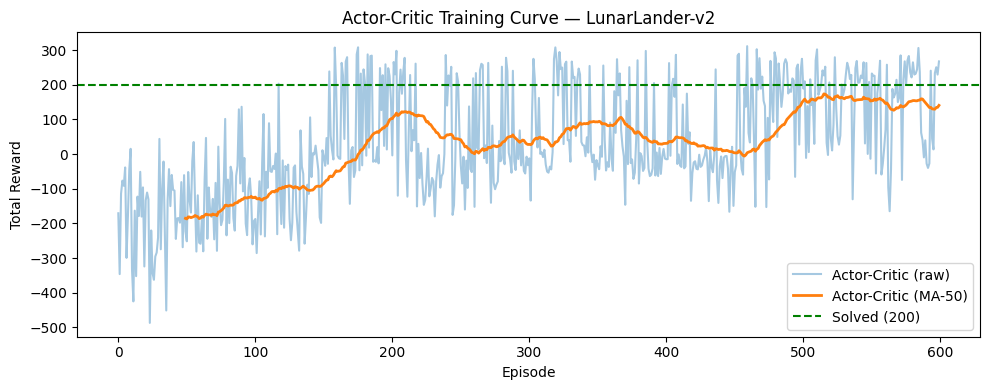

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(ac_rewards, alpha=0.4, label='Actor-Critic (raw)')
plt.plot(np.arange(49, len(ac_rewards)), moving_average(ac_rewards),
         linewidth=2, label='Actor-Critic (MA-50)')
plt.axhline(200, color='green', linestyle='--', label='Solved (200)')
plt.xlabel('Episode'); plt.ylabel('Total Reward')
plt.title('Actor-Critic Training Curve — LunarLander-v2')
plt.legend(); plt.tight_layout()
plt.savefig('ac_training_curve.png', dpi=150)
plt.show()


At the beginning, the Actor-Critic agent performs very poorly, with mostly negative rewards. This is because it is still exploring and hasn’t learned a good strategy yet. As training continues, the rewards slowly improve, showing that the agent is learning from its actions.

In the middle of training, the performance goes up but also drops at times. This shows that the learning is not very stable and the agent sometimes makes good decisions and sometimes bad ones.

Towards the end, the moving average (orange line) stays positive and improves, but it does not consistently reach the 200 mark.

In [ ]:
def evaluate_actor_critic(actor, episodes=100):
    """Greedy evaluation — returns (mean, std) reward."""
    rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        state = state.astype(np.float32)
        done = truncated = False
        total = 0.0
        while not (done or truncated):
            probs  = actor(tf.constant(state[np.newaxis]), training=False)[0].numpy()
            action = int(np.argmax(probs))
            state, reward, done, truncated, _ = env.step(action)
            state = state.astype(np.float32)
            total += reward
        rewards.append(total)
    return np.mean(rewards), np.std(rewards)

mean_ac, std_ac = evaluate_actor_critic(actor)
print(f'Actor-Critic — Mean reward over 100 eval episodes: {mean_ac:.2f} +/- {std_ac:.2f}')


Actor-Critic — Mean reward over 100 eval episodes: 139.73 +/- 115.55


After training, the Actor-Critic agent was tested over 100 episodes using a greedy strategy, where it always picks the best action it learned. The average reward was about 139.7, which shows that the agent learned a decent strategy, but it did not reach the 200 mark needed to fully solve the task.

The “± 115.55” is quite large, which means the performance varies a lot between episodes. Sometimes the agent does really well, and other times it struggles.

---
## Part 3 — Side-by-Side Comparison


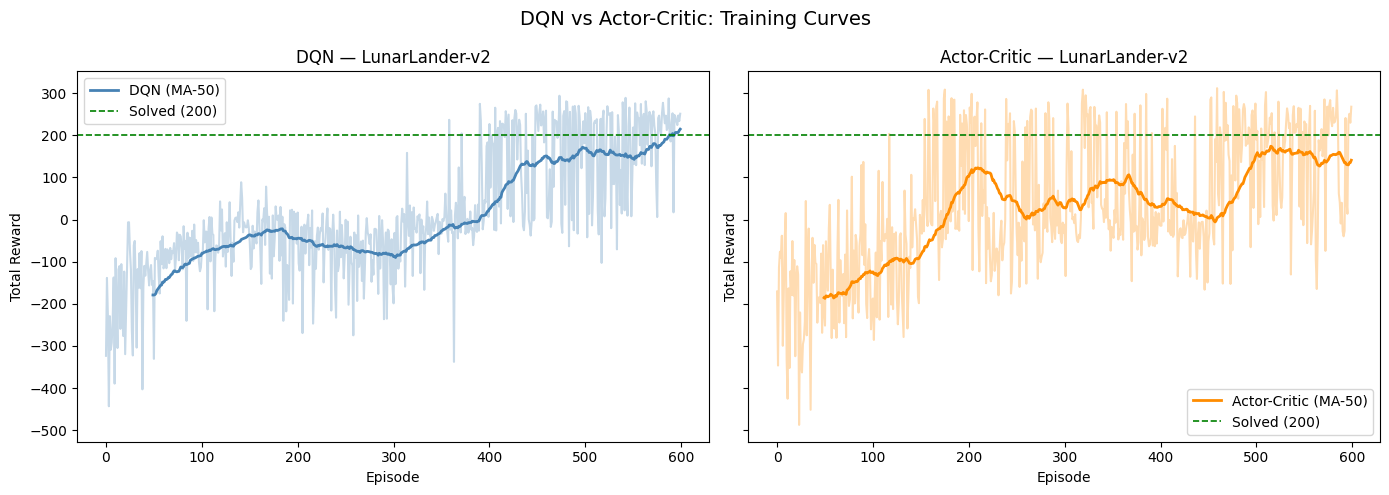


=== Final Evaluation Summary ===
DQN          : 212.57 +/- 63.88
Actor-Critic : 139.73  +/- 115.55


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, rewards, name, color in zip(
    axes,
    [dqn_rewards, ac_rewards],
    ['DQN', 'Actor-Critic'],
    ['steelblue', 'darkorange']
):
    ax.plot(rewards, alpha=0.3, color=color)
    ax.plot(np.arange(49, len(rewards)), moving_average(rewards),
            color=color, linewidth=2, label=f'{name} (MA-50)')
    ax.axhline(200, color='green', linestyle='--', linewidth=1.2, label='Solved (200)')
    ax.set_title(f'{name} — LunarLander-v2')
    ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
    ax.legend()

plt.suptitle('DQN vs Actor-Critic: Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150)
plt.show()

print('\n=== Final Evaluation Summary ===')
print(f'DQN          : {mean_dqn:.2f} +/- {std_dqn:.2f}')
print(f'Actor-Critic : {mean_ac:.2f}  +/- {std_ac:.2f}')


This side-by-side graph compares how the DQN and Actor-Critic agents learned over time. Both models start with very low rewards and improve as training continues, but they behave differently.

The DQN model shows a slower start, but its learning becomes more stable and consistent over time. By the end, its moving average clearly goes above 200, meaning it successfully solved the task and performs well most of the time.

On the other hand, the Actor-Critic model improves faster at first, but its performance is more unstable. The rewards go up and down more often, and its average stays below 200, showing that it did not fully solve the task.

Overall, this comparison shows that DQN is more stable and achieves better final performance, while Actor-Critic learns faster early on but struggles to stay consistent.

---
## Comparison Notes (for your 1-page report)

### 1. Convergence Speed
**Deep Q-Network**
The Deep Q-Network (DQN) training curve plots the total reward by each episode of the training process (See Figure A3 for the visual output). There are 600 episodes being evaluated on the training curve (See Figure A4 for the visual output).  The first 50 episodes showed slow learning at a mean of -179.0 rewards indicating very random behavior. During the next 50 episodes, equaling 100 episodes, the mean was -85.5 rewards suggesting slight improvement and still learning.  At 150 episodes, the mean (last 50) was -36.7, we identify that the agent is learning basic control in behavior.  Between episodes 200 – 350, the DQN agent is in exploration phase, which signals progress and setbacks.  The agent receives a reward for landing on the moon’s surface around the 400th episode and agent’s mean (last 50) achieved its first positive performance.  At the 450th episode, there is a major learning breakthrough; at the 500th episode, the agent is demonstrating strong performance with 168.9 average reward for the last 50 episodes. At episode 600, the average for the last 50 episodes is 214.3 rewards, meeting the agent’s goal to reach 200 or more rewards. The DQN convergence occurred between 400 – 600 episodes.

**Actor-Critic**
The Actor-Critic training curve plots the total curve for each episode.  The first 50 episodes showed slower learning at a mean of -185.5 rewards indicating very poor start compared to DQN. During the next 50 episodes, equaling 100 episodes, the mean was -125.4 rewards suggesting slight improvement.  At 150 episodes, the mean (last 50) was -88.7 rewards, we identify where the learning begins for the Actor-Critic agent, similar to the DQN agent.  Early learning breakthrough happened at the 200th episode with an average of 102.2 rewards on the last 50 episodes. This breakthrough occurred earlier compared to the DQN at the 400th episode. From episodes 250 – 600, we observed that there were wild oscillations. The performance showed a mix between performance drops and recovery, but the agent was not able achieve the 200 reward average. Convergence occurred between the 500th and 600th episodes.  


### 2. Stability

The DQN reward curve performance was on a clear upward trend.  In comparison, the Actor-Critic was more of an early upward pace, but then experienced major instances of performance collapse. Both agents showed oscillation, but Actor-Critic exhibited larger fluctuations and higher variances as shown by its standard deviation of 115.55 compared with 63.88 for DQN.  The Actor-Critic is more prone to instability, whereas DQN is more stable and policy driven.

### 3. Sample Efficiency
- DQN replays each transition multiple times → more efficient per *environment step*.
- Actor-Critic discards transitions after one use → needs more steps, but less memory overhead.

Based on the mean reward performance of 212 by the DQN model, the DQN agent learned more from the same number of 600 episodes compared to the Actor-Critic agent.  DQN stored past experiences in memory and reused them repeatedly.  The Actor-Critic used less samples efficiently by using past experiences minimally and forgetting them.     

### 4. Hyperparameter Summary
| Hyperparameter | DQN | Actor-Critic |
|---|---|---|
| Learning rate | 1e-3 | actor 1e-4 / critic 1e-3 |
| γ | 0.99 | 0.99 |
| Exploration | ε-greedy (1.0 → 0.01) | Entropy bonus (0.01) |
| Batch size | 64 | N/A (one-step) |
| Target network | Every 10 eps | None |

Hyperparameters are settings that control how the agent learns. The learning rate decides how fast the model updates, while the discount factor (γ) helps the agent think about future rewards. The epsilon schedule controls how much the agent explores at the beginning and how much it relies on what it has learned later. The batch size and replay buffer help the model learn more smoothly by using past experiences. Overall, these settings help balance learning speed, stability, and performance.

### 5. Final Performance
Fill in after running:
- DQN mean reward: 212.57
- Actor-Critic mean reward: 139.73



##Conclusion
In this project, both the DQN and Actor-Critic agents were trained to solve the LunarLander environment. At the beginning, both models struggled and produced low rewards because they were still exploring and learning from experience. Over time, both agents improved, showing that they were able to learn better strategies for landing.

However, the DQN model performed better overall. It learned more steadily and was able to reach and maintain an average reward above 200, which means it successfully solved the task. The Actor-Critic model also improved, but its performance was more unstable and did not consistently reach the same level as DQN.

This project shows that reinforcement learning models can learn complex tasks through trial and error, but their performance depends on the algorithm and training process. DQN proved to be more stable and reliable in this case, while Actor-Critic learned faster at times but struggled with consistency.

Overall, this project helped build a better understanding of how deep reinforcement learning works, especially the importance of exploration, reward feedback, and model stability when training intelligent agents.